# 0. Official Preprocessed Data Load

04_Preprocessing에서 생성한 공식 전처리 데이터를 불러온다.

- Full Datetime 기반 전처리
- Normal: 19,999 rows / 599 segments
- Abnormal: 600 rows / 21 segments
- median sampling interval ≈ 0.1 s
- Gap을 기준으로 생성된 공식 `segment_id`를 그대로 사용
- 05_EDA_Cycle에서는 timestamp, dt, segment를 재생성하지 않음

# 05. EDA Cycle Analysis

## 분석 목적

Normal 데이터에서 반복적인 시간구조가 존재하는지 확인하고,  
AI0_Vibration / AI1_Vibration / AI2_Current 중 Cycle의 시간 기준으로 사용할 수 있는 신호를 탐색한다.

분석 순서는 다음과 같다.

1. Peak Interval / ACF / PSD를 이용한 반복주기 탐색
2. 반복성이 가장 안정적인 신호를 Cycle Anchor 후보로 선정
3. Anchor의 Peak-to-Peak 기준으로 Normal Cycle Candidate 추출
4. Cycle Duration 안정성 검증
5. Phase-normalized waveform 및 Template consistency 검증

---

## 데이터 기준

04_Preprocessing에서 생성한 공식 전처리 데이터를 사용한다.

- Normal: 19,999 rows / 599 segments
- Abnormal: 600 rows / 21 segments
- 저장 간격 중앙값: 약 0.1 s
- 저장 데이터 기준 sampling frequency: 약 10 Hz
- Nyquist frequency: 약 5 Hz
- 모든 분석은 공식 `segment_id` 내부에서만 수행
- Gap을 넘어 서로 다른 segment를 연결하지 않음
- TimeStamp / elapsed_sec / dt_sec / segment_id를 05에서 다시 생성하지 않음

---

## 특이사항

### 1. 약 10 Hz는 원 센서의 실제 취득주파수라고 확정할 수 없음

현재 데이터에서 확인 가능한 것은 저장된 행 간격이 약 0.1초라는 사실이다.

따라서 본 분석에서는 저장 데이터 기준으로 약 10 Hz를 사용하지만,
원 센서가 실제로 10 Hz로 측정했는지 또는 고주파 신호를 내부 처리 후 10 Hz로 저장했는지는 알 수 없다.

따라서 5 Hz 이상의 실제 진동 주파수 성분을 복원하거나 분석할 수 없다.

### 2. 약 1.6~1.7초 반복구조를 실제 Press Cycle로 확정하지 않음

Peak / ACF / PSD 및 Cycle Candidate 분석에서 확인되는 약 1.6~1.7초 구조는
현재 데이터에서 관찰되는 `AI2_Current 반복주기 후보`이다.

실제 Fine Blanking Stroke/Cycle임을 확정하려면
PLC Cycle Counter, Ram Position, 생산속도, 운전로그 등의 외부 기준이 필요하다.

### 3. AI2_Current는 Cycle Anchor 후보이지 물리적 위치센서가 아님

AI2_Current의 반복성이 AI0/AI1보다 안정적으로 나타날 경우
Cycle의 시간 및 Phase를 정렬하기 위한 Anchor 후보로 사용한다.

이는 Current가 Vibration을 발생시킨다는 인과관계나
AI2가 실제 프레스 위치를 직접 측정한다는 의미가 아니다.

### 4. 후반부 Normal 데이터에서 별도의 Signal Regime 후보가 관찰됨

전체 Normal 시계열 후반부에서 AI0/AI1 진동 변동폭과
AI2 신호 특성이 이전 구간과 다르게 보이는 영역이 존재한다.

현재 단계에서는 원인을 추정하지 않으며,
별도의 Operating Regime 분석에서 반복주기 / amplitude / waveform shape 변화를 검증한다.

---

## Peak `distance` 파라미터

`scipy.signal.find_peaks()`의 `distance`는

> 서로 다른 두 Peak 사이에 허용되는 최소 sample 간격

을 의미한다.

현재 저장간격이 약 0.1초이므로:

- `distance=3`  → Peak 사이 최소 약 0.3초
- `distance=12` → Peak 사이 최소 약 1.2초

본 Notebook에서는 두 값을 서로 다른 목적으로 사용한다.

### `distance=3` : 초기 Periodicity 탐색

AI0 / AI1 / AI2 각각에 어떤 반복구조가 존재하는지 넓게 탐색하기 위한 값이다.

아직 Cycle 주기를 정하지 않은 상태이므로 짧은 반복구조까지 탐색할 수 있도록
최소 Peak 간격을 3 samples로 설정한다.

따라서 이 단계는 `Cycle 검출`이 아니라 `반복주기 탐색`이다.

### `distance=12` : AI2 Cycle Candidate 추출

Peak / ACF / PSD 분석 후 AI2_Current에서 약 1.6~1.7초의
안정적인 반복구조가 확인된 뒤 Cycle Candidate를 추출할 때 사용한다.

`distance=12`는 서로 1.2초보다 가까운 Peak를 동시에 Cycle 경계로 선택하지 않도록 제한한다.

즉,

`distance=3`
→ 어떤 반복주기가 존재하는지 탐색

`distance=12`
→ 확인된 AI2 반복구조를 Peak-to-Peak Cycle Candidate로 추출

이라는 역할 차이가 있다.

**주의:** `distance=12` 자체가 1.7초 Cycle을 만들어내는 것은 아니다.
최소 Peak 간격만 1.2초로 제한하며 실제 Cycle Duration은 검출된 인접 Peak의 시간 차이에서 계산한다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, periodogram

def find_data_dir():
    for root in [Path.cwd(), *Path.cwd().parents]:
        d=root/"data"
        if (d/"processed"/"preprocessed_data.csv").exists():
            return d
    raise FileNotFoundError("data/processed/preprocessed_data.csv를 찾지 못함")

DATA_DIR=find_data_dir()
DATA_PATH=DATA_DIR/"processed"/"preprocessed_data.csv"

data=pd.read_csv(DATA_PATH,parse_dates=["TimeStamp"])

REQUIRED_COLUMNS=[
    "TimeStamp","AI0_Vibration","AI1_Vibration","AI2_Current",
    "Equipment_state","source_row","elapsed_sec","dt_sec",
    "segment_id","pos_in_seg","seg_len","source"
]

missing=sorted(set(REQUIRED_COLUMNS)-set(data.columns))
if missing:
    raise ValueError(f"Missing columns: {missing}")

CHANNELS=["AI0_Vibration","AI1_Vibration","AI2_Current"]
SAMPLE_RATE_HZ=10.0
MIN_SEGMENT_ROWS=30
MIN_PERIOD_SEC=.3
MAX_PERIOD_SEC=4.0

normal=data[data["source"]=="normal"].copy()
outlier=data[data["source"]=="abnormal"].copy()

summary=pd.DataFrame({
    "rows":[len(normal),len(outlier)],
    "segments":[normal["segment_id"].nunique(),outlier["segment_id"].nunique()],
    "median_dt_sec":[normal["dt_sec"].dropna().median(),outlier["dt_sec"].dropna().median()],
    "time_start":[normal["TimeStamp"].min(),outlier["TimeStamp"].min()],
    "time_end":[normal["TimeStamp"].max(),outlier["TimeStamp"].max()]
},index=["Normal","Abnormal"])

print("DATA_PATH:",DATA_PATH)
display(summary)

DATA_PATH: c:\Users\astra\Desktop\K_eng\data\processed\preprocessed_data.csv


,rows,segments,median_dt_sec,time_start,time_end
Normal,19999,599,0.1,2022-07-12 00:00:00.019,2022-07-12 01:16:55.828
Abnormal,600,21,0.1,2022-07-17 10:51:07.943,2022-07-17 10:53:53.540


In [2]:
from scipy.signal import find_peaks, periodogram

CHANNELS=["AI0_Vibration","AI1_Vibration","AI2_Current"]
SAMPLE_RATE_HZ=10.0
MIN_SEGMENT_ROWS=30
MIN_PERIOD_SEC=.3
MAX_PERIOD_SEC=4.0

def segment_acf(values,max_lag):
    x=np.asarray(values,dtype=float)
    x=x-x.mean()
    denominator=np.dot(x,x)
    if denominator<=0:return None
    acf=np.correlate(x,x,mode="full")[len(x)-1:]
    return acf[:max_lag+1]/denominator

def analyze_channel(df,column):
    max_lag=min(int(MAX_PERIOD_SEC*SAMPLE_RATE_HZ),40)
    min_lag=max(1,int(np.ceil(MIN_PERIOD_SEC*SAMPLE_RATE_HZ)))
    acf_sum=np.zeros(max_lag+1)
    acf_weight=np.zeros(max_lag+1)
    spectra=[]
    peak_intervals=[]
    eligible_segments=0
    frequencies=np.fft.rfftfreq(256,d=1/SAMPLE_RATE_HZ)

    for _,group in df.groupby("segment_id",sort=False):
        if len(group)<MIN_SEGMENT_ROWS:continue

        x=group[column].to_numpy(float)
        if not np.isfinite(x).all():continue
        eligible_segments+=1

        acf=segment_acf(x,min(max_lag,len(x)-1))
        if acf is not None:
            acf_sum[:len(acf)]+=acf*len(x)
            acf_weight[:len(acf)]+=len(x)

        _,power=periodogram(
            x,fs=SAMPLE_RATE_HZ,nfft=256,
            detrend="constant",scaling="spectrum"
        )
        if power.max()>0:
            spectra.append(power/power.max())

        smooth=pd.Series(x).rolling(3,center=True,min_periods=1).median().to_numpy()
        prominence=max(float(np.std(smooth,ddof=1))*.5,np.finfo(float).eps)
        peaks,_=find_peaks(smooth,distance=3,prominence=prominence)

        if len(peaks)>1:
            peak_intervals.extend(np.diff(peaks)/SAMPLE_RATE_HZ)

    aggregated_acf=np.divide(
        acf_sum,acf_weight,
        out=np.full_like(acf_sum,np.nan),
        where=acf_weight>0
    )

    acf_peaks,_=find_peaks(
        np.nan_to_num(aggregated_acf,nan=0.0),
        distance=2,prominence=.05
    )
    acf_peaks=[
        lag for lag in acf_peaks
        if min_lag<=lag<=max_lag
    ]
    acf_peaks=sorted(
        acf_peaks,
        key=lambda lag:aggregated_acf[lag],
        reverse=True
    )

    mean_power=np.mean(spectra,axis=0) if spectra else np.array([])
    band=(frequencies>=1/MAX_PERIOD_SEC)&(frequencies<=1/MIN_PERIOD_SEC)

    if len(mean_power) and np.any(band):
        band_idx=np.flatnonzero(band)
        top_idx=band_idx[np.argmax(mean_power[band_idx])]
        psd_period=float(1/frequencies[top_idx])
    else:
        psd_period=np.nan

    intervals=np.asarray(peak_intervals,dtype=float)

    return {
        "channel":column,
        "eligible_segments":eligible_segments,
        "peak_intervals_count":len(intervals),
        "peak_interval_median_sec":float(np.median(intervals)) if len(intervals) else np.nan,
        "peak_interval_q25_sec":float(np.quantile(intervals,.25)) if len(intervals) else np.nan,
        "peak_interval_q75_sec":float(np.quantile(intervals,.75)) if len(intervals) else np.nan,
        "acf_top_lag_sec":acf_peaks[0]/SAMPLE_RATE_HZ if acf_peaks else np.nan,
        "acf_top_value":float(aggregated_acf[acf_peaks[0]]) if acf_peaks else np.nan,
        "psd_top_period_sec":psd_period,
        "acf":aggregated_acf,
        "frequencies":frequencies,
        "power":mean_power,
        "peak_intervals_sec":intervals
    }

normal_cycle_results={
    channel:analyze_channel(normal,channel)
    for channel in CHANNELS
}

periodicity_summary=pd.DataFrame([
    {
        "channel":r["channel"],
        "eligible_segments":r["eligible_segments"],
        "peak_intervals_count":r["peak_intervals_count"],
        "peak_interval_median_sec":r["peak_interval_median_sec"],
        "peak_interval_q25_sec":r["peak_interval_q25_sec"],
        "peak_interval_q75_sec":r["peak_interval_q75_sec"],
        "acf_top_lag_sec":r["acf_top_lag_sec"],
        "acf_top_value":r["acf_top_value"],
        "psd_top_period_sec":r["psd_top_period_sec"]
    }
    for r in normal_cycle_results.values()
])

display(periodicity_summary)

,channel,eligible_segments,peak_intervals_count,peak_interval_median_sec,peak_interval_q25_sec,peak_interval_q75_sec,acf_top_lag_sec,acf_top_value,psd_top_period_sec
0,AI0_Vibration,360,1535,0.7,0.6,0.9,0.6,0.446058,0.556522
1,AI1_Vibration,360,2018,0.6,0.5,0.6,1.1,0.594477,0.556522
2,AI2_Current,360,475,1.7,1.6,1.7,1.6,0.622361,1.706667


In [4]:
CYCLE_ANCHOR="AI2_Current"
CYCLE_MIN_PEAK_DISTANCE_SAMPLES=12
TEMPLATE_PHASE_POINTS=101

cycle_records=[]
cycle_waveforms=[]
phase=np.linspace(0,1,TEMPLATE_PHASE_POINTS)

for segment_id,group in normal.groupby("segment_id",sort=False):
    if len(group)<MIN_SEGMENT_ROWS:
        continue

    anchor=group[CYCLE_ANCHOR].to_numpy(float)
    smooth=pd.Series(anchor).rolling(3,center=True,min_periods=1).median().to_numpy()
    prominence=max(float(np.std(smooth,ddof=1))*.5,np.finfo(float).eps)
    peaks,_=find_peaks(
        smooth,
        distance=CYCLE_MIN_PEAK_DISTANCE_SAMPLES,
        prominence=prominence
    )

    for cycle_number,(start,stop) in enumerate(zip(peaks[:-1],peaks[1:]),start=1):
        if stop-start<CYCLE_MIN_PEAK_DISTANCE_SAMPLES:
            continue

        cycle=group.iloc[start:stop+1]
        duration=float(cycle["elapsed_sec"].iloc[-1]-cycle["elapsed_sec"].iloc[0])
        if duration<=0:
            continue

        record={
            "segment_id":segment_id,
            "cycle_number_in_segment":cycle_number,
            "start_source_row":int(cycle["source_row"].iloc[0]),
            "end_source_row":int(cycle["source_row"].iloc[-1]),
            "duration_sec":duration,
            "n_samples":len(cycle)
        }

        cycle_phase=np.linspace(0,1,len(cycle))

        for channel in CHANNELS:
            x=cycle[channel].to_numpy(float)
            mean_square=float(np.mean(x**2))
            rms=float(np.sqrt(mean_square))

            record[f"{channel}_mean"]=float(np.mean(x))
            record[f"{channel}_std"]=float(np.std(x,ddof=1))
            record[f"{channel}_rms"]=rms
            record[f"{channel}_peak_to_peak"]=float(np.ptp(x))
            record[f"{channel}_mean_square"]=mean_square
            record[f"{channel}_energy"]=float(np.sum(x**2))
            record[f"{channel}_crest_factor"]=float(np.max(np.abs(x))/rms) if rms>0 else np.nan

            cycle_waveforms.append({
                "segment_id":segment_id,
                "cycle_number_in_segment":cycle_number,
                "channel":channel,
                "phase":phase.copy(),
                "values":np.interp(phase,cycle_phase,x)
            })

        cycle_records.append(record)

cycle_features=pd.DataFrame(cycle_records)

if cycle_features.empty:
    raise ValueError("No Normal Cycle Candidates were formed.")

cycle_templates={}
for channel in CHANNELS:
    waves=np.vstack([
        item["values"]
        for item in cycle_waveforms
        if item["channel"]==channel
    ])
    cycle_templates[channel]=np.median(waves,axis=0)

segments_with_cycles=cycle_features["segment_id"].nunique()

print(f"Cycle candidates : {len(cycle_features)}")
print(f"Segments w/cycle : {segments_with_cycles} / {normal['segment_id'].nunique()}")
print(f"Duration median  : {cycle_features['duration_sec'].median():.2f} s")
print(
    f"Duration IQR     : "
    f"{cycle_features['duration_sec'].quantile(.25):.2f} ~ "
    f"{cycle_features['duration_sec'].quantile(.75):.2f} s"
)

display(cycle_features.head())

Cycle candidates : 475
Segments w/cycle : 338 / 599
Duration median  : 1.70 s
Duration IQR     : 1.60 ~ 1.70 s


,segment_id,cycle_number_in_segment,start_source_row,end_source_row,duration_sec,n_samples,AI0_Vibration_mean,AI0_Vibration_std,AI0_Vibration_rms,AI0_Vibration_peak_to_peak,...,AI1_Vibration_mean_square,AI1_Vibration_energy,AI1_Vibration_crest_factor,AI2_Current_mean,AI2_Current_std,AI2_Current_rms,AI2_Current_peak_to_peak,AI2_Current_mean_square,AI2_Current_energy,AI2_Current_crest_factor
0,N0000,1,17,34,1.7,18,-0.013839,0.074322,0.073542,0.320468,...,0.027283,0.491093,1.615857,16.322078,159.118021,155.493952,439.24885,24178.369066,435210.643180,1.414406
1,N0001,1,53,70,1.7,18,0.008140,0.081634,0.079751,0.244890,...,0.018462,0.332308,1.698016,14.894984,152.289846,148.746773,433.55648,22125.602425,398260.843641,1.462473
2,N0004,1,125,142,1.7,18,-0.016340,0.030694,0.034011,0.105994,...,0.002451,0.044113,2.102431,8.301663,85.836268,83.829927,221.30086,7027.456729,126494.221115,1.327636
3,N0005,1,164,181,1.7,18,-0.016352,0.057693,0.058403,0.201815,...,0.022906,0.412306,1.694571,16.625710,159.593477,155.985537,441.70707,24331.487779,437966.780013,1.421493
4,N0005,2,181,197,1.6,17,0.019753,0.071407,0.072036,0.273807,...,0.020285,0.344852,1.629790,4.864406,158.286431,153.637421,438.96752,23604.457167,401275.771834,1.443218


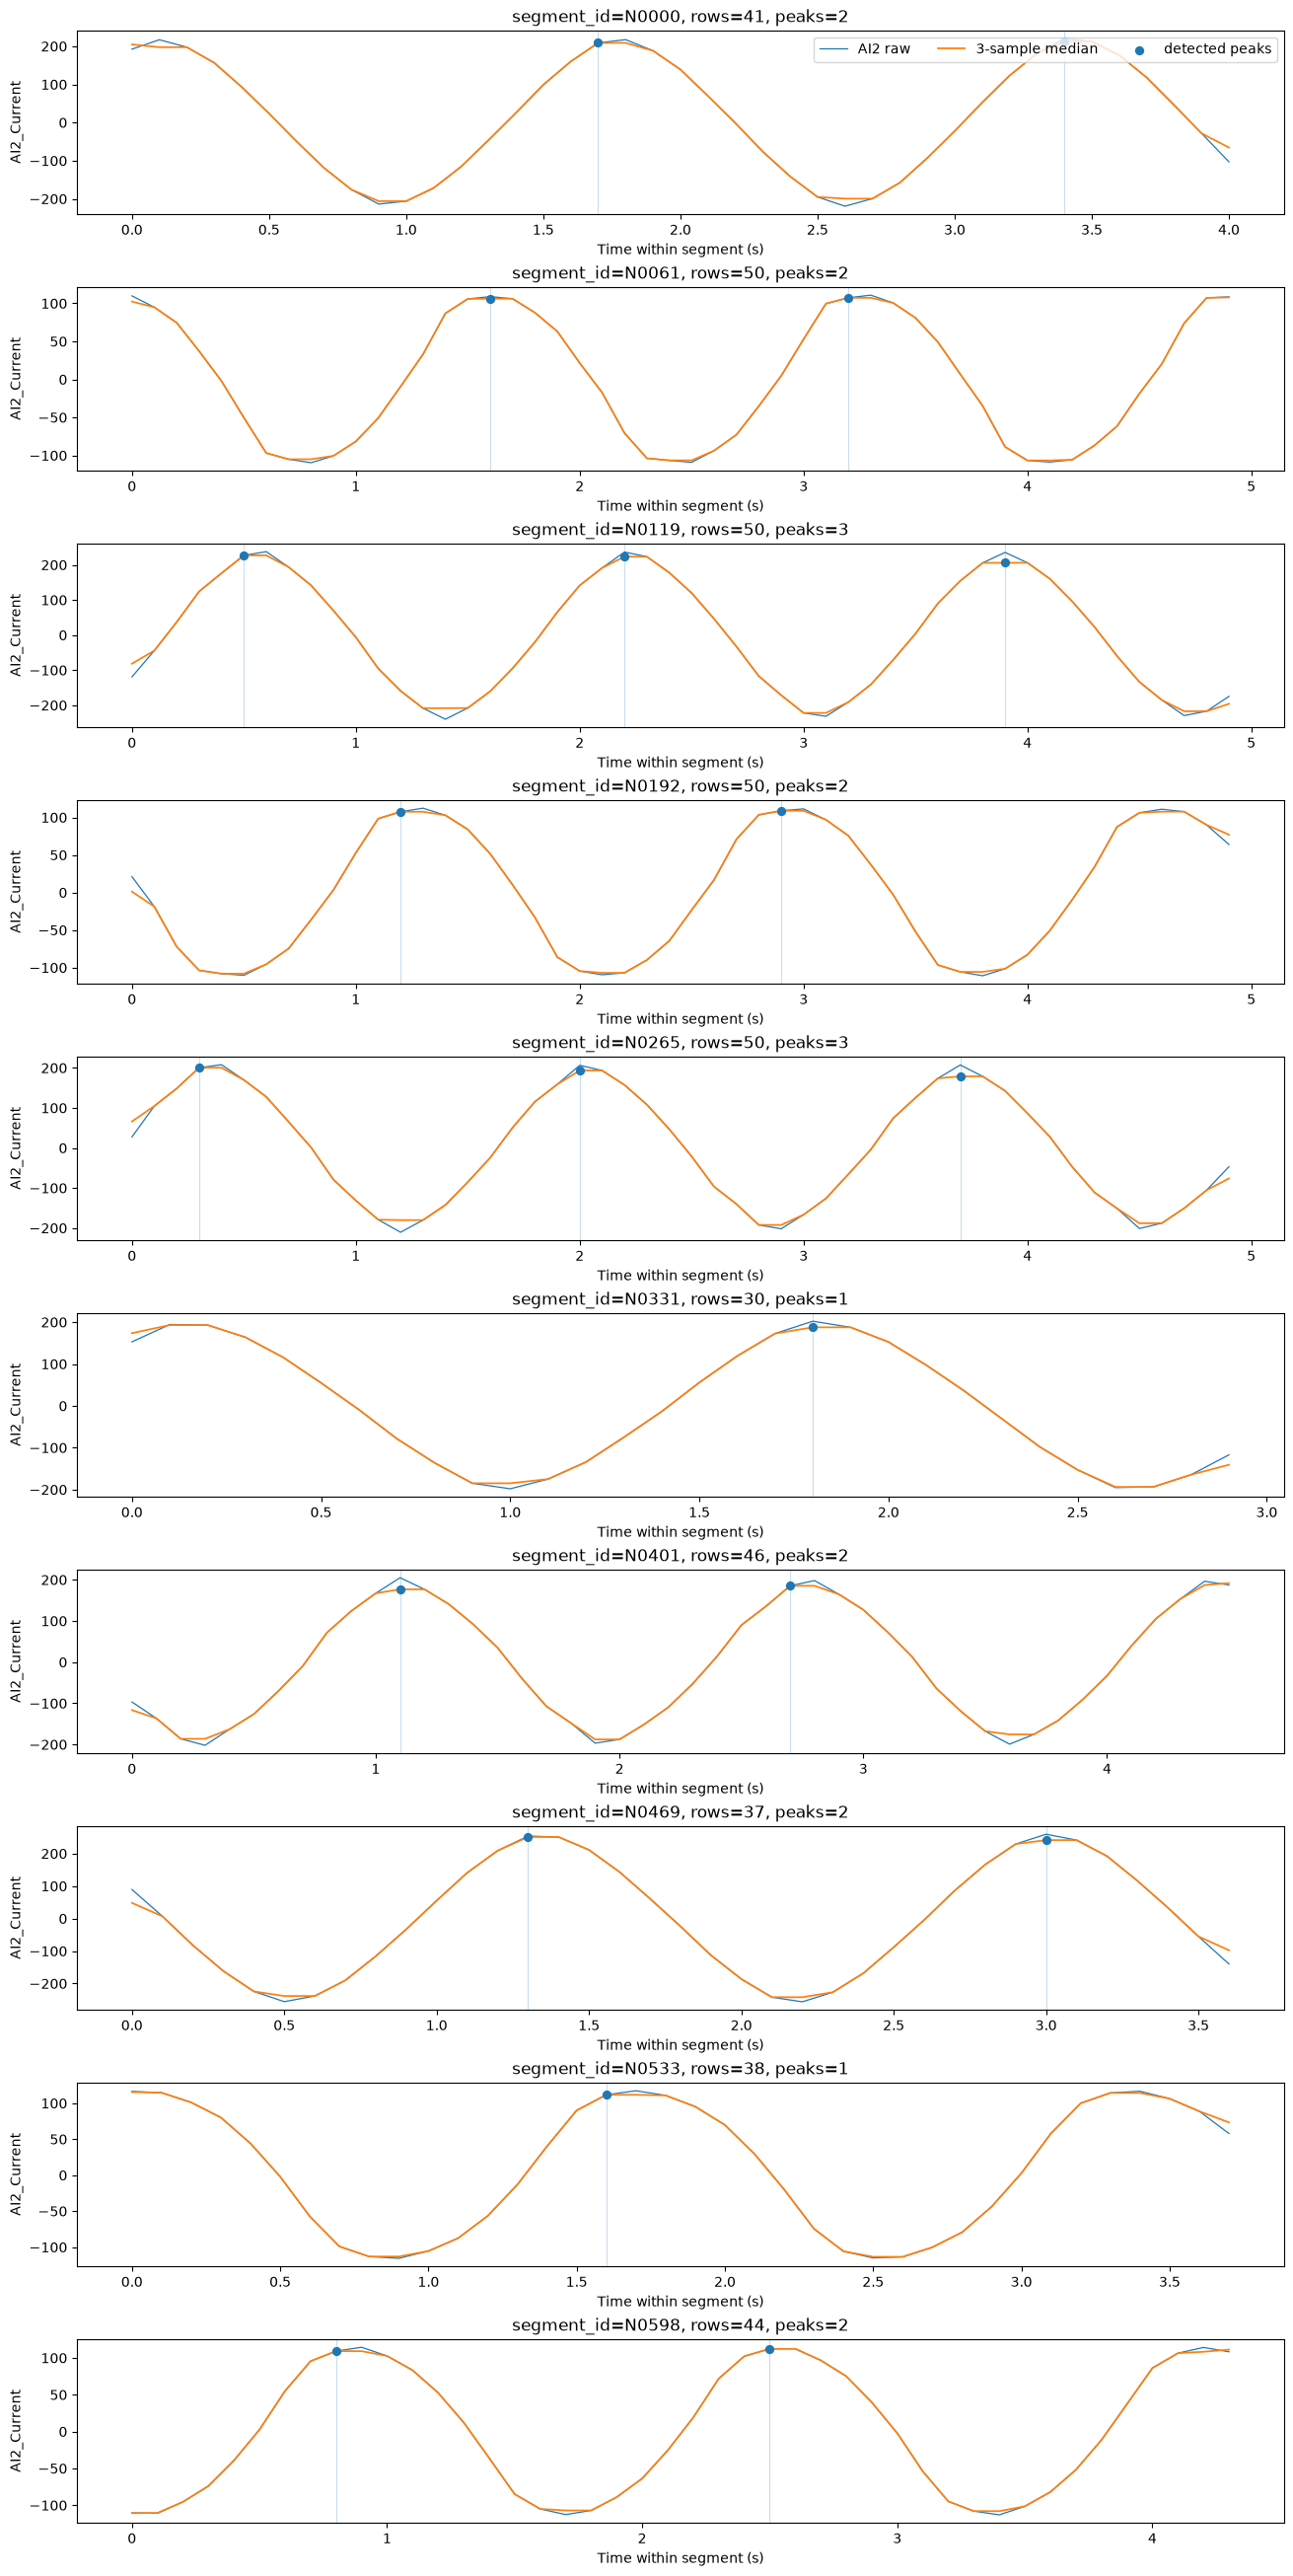

Displayed 10 eligible Normal segments.
Detected peaks indicate candidate Peak-to-Peak cycle boundaries.


In [6]:
eligible_sizes=normal.groupby("segment_id",sort=False).size()
eligible_segments=eligible_sizes[eligible_sizes>=MIN_SEGMENT_ROWS].index.to_numpy()

idx=np.unique(np.linspace(0,len(eligible_segments)-1,min(10,len(eligible_segments)),dtype=int))
selected_segments=eligible_segments[idx]

fig,axes=plt.subplots(len(selected_segments),1,figsize=(13,2.6*len(selected_segments)),squeeze=False,constrained_layout=True)

for row,segment_id in enumerate(selected_segments):
    ax=axes[row,0]
    group=normal[normal["segment_id"]==segment_id]

    raw=group[CYCLE_ANCHOR].to_numpy(float)
    smooth=pd.Series(raw).rolling(3,center=True,min_periods=1).median().to_numpy()
    prominence=max(float(np.std(smooth,ddof=1))*.5,np.finfo(float).eps)
    peaks,_=find_peaks(smooth,distance=CYCLE_MIN_PEAK_DISTANCE_SAMPLES,prominence=prominence)

    time=group["elapsed_sec"].to_numpy(float)-group["elapsed_sec"].iloc[0]

    ax.plot(time,raw,lw=.9,label="AI2 raw")
    ax.plot(time,smooth,lw=1.25,label="3-sample median")
    ax.scatter(time[peaks],smooth[peaks],s=32,label="detected peaks",zorder=3)

    for peak in peaks:
        ax.axvline(time[peak],alpha=.24,lw=.8)

    ax.set_title(f"segment_id={segment_id}, rows={len(group)}, peaks={len(peaks)}")
    ax.set_xlabel("Time within segment (s)")
    ax.set_ylabel(CYCLE_ANCHOR)

    if row==0:
        ax.legend(loc="upper right",ncol=3)

plt.show()
print(f"Displayed {len(selected_segments)} eligible Normal segments.")
print("Detected peaks indicate candidate Peak-to-Peak cycle boundaries.")

,Normal cycle duration
count,475.000000
mean,1.667368
std,0.046936
min,1.600000
Q1,1.600000
median,1.700000
Q3,1.700000
max,1.700000
CV,0.028150
fraction_1.6_to_1.7,1.000000


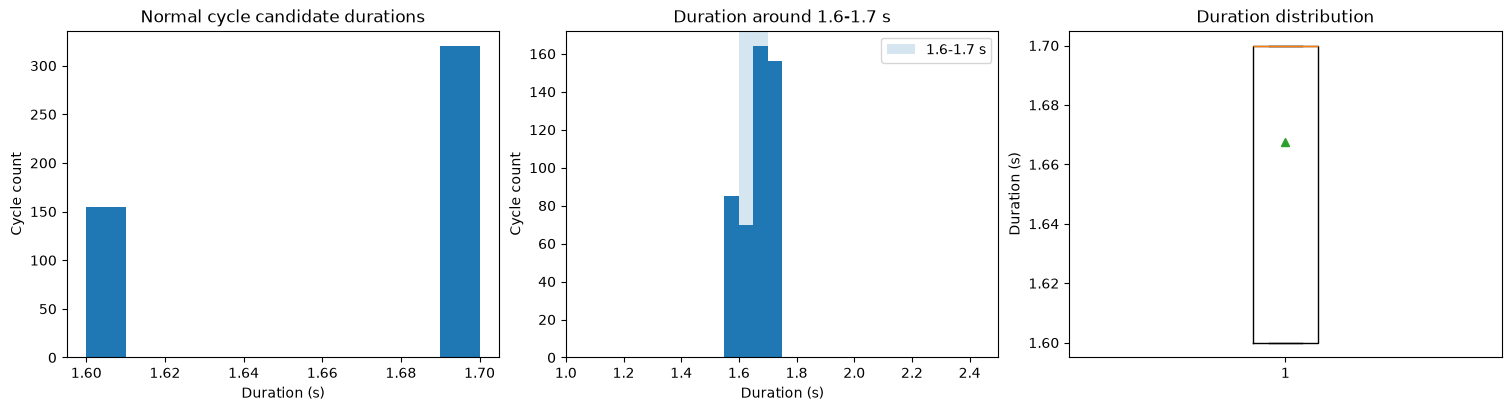

In [7]:
normal_durations=cycle_features["duration_sec"].dropna().astype(float)

duration_summary=pd.Series({
    "count":len(normal_durations),
    "mean":normal_durations.mean(),
    "std":normal_durations.std(),
    "min":normal_durations.min(),
    "Q1":normal_durations.quantile(.25),
    "median":normal_durations.median(),
    "Q3":normal_durations.quantile(.75),
    "max":normal_durations.max(),
    "CV":normal_durations.std()/normal_durations.mean(),
    "fraction_1.6_to_1.7":normal_durations.round(1).between(1.6,1.7,inclusive="both").mean()
},name="Normal cycle duration")

display(duration_summary.to_frame())

fig,axes=plt.subplots(1,3,figsize=(15,4),constrained_layout=True)

axes[0].hist(normal_durations,bins="auto")
axes[0].set(title="Normal cycle candidate durations",xlabel="Duration (s)",ylabel="Cycle count")

axes[1].hist(normal_durations,bins=np.arange(1.0,2.51,.05))
axes[1].axvspan(1.6,1.7,alpha=.18,label="1.6-1.7 s")
axes[1].set_xlim(1.0,2.5)
axes[1].set(title="Duration around 1.6-1.7 s",xlabel="Duration (s)",ylabel="Cycle count")
axes[1].legend()

axes[2].boxplot(normal_durations,showmeans=True)
axes[2].set(title="Duration distribution",ylabel="Duration (s)")

plt.show()

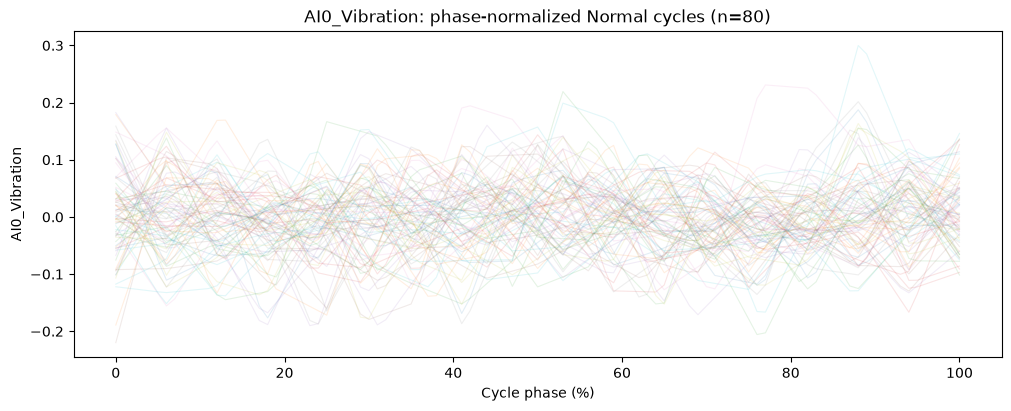

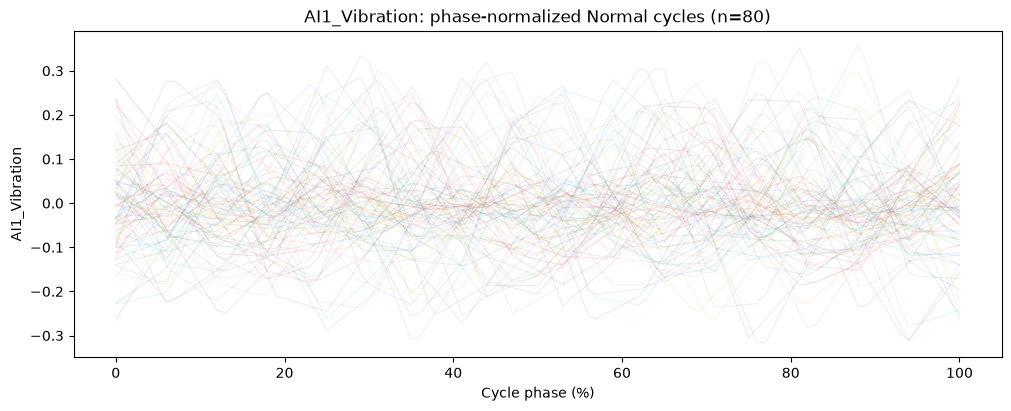

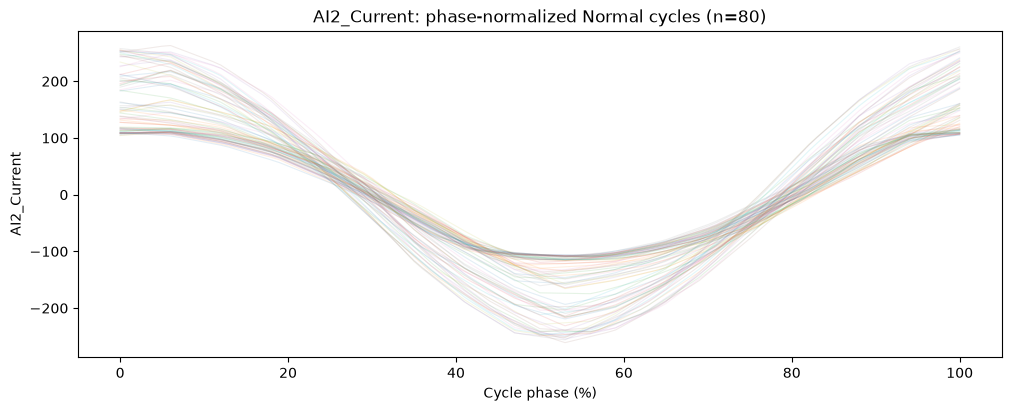

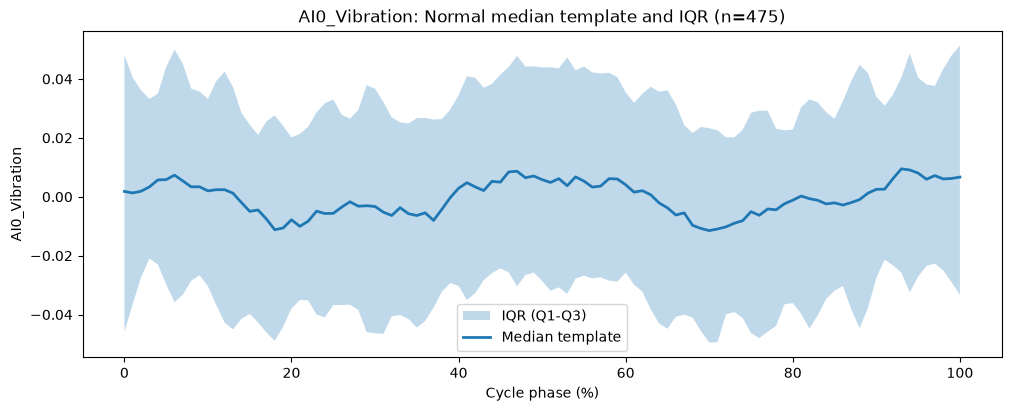

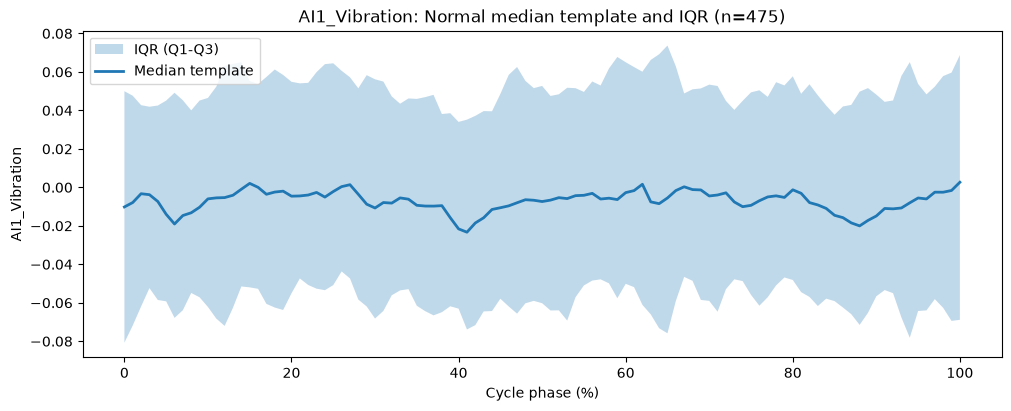

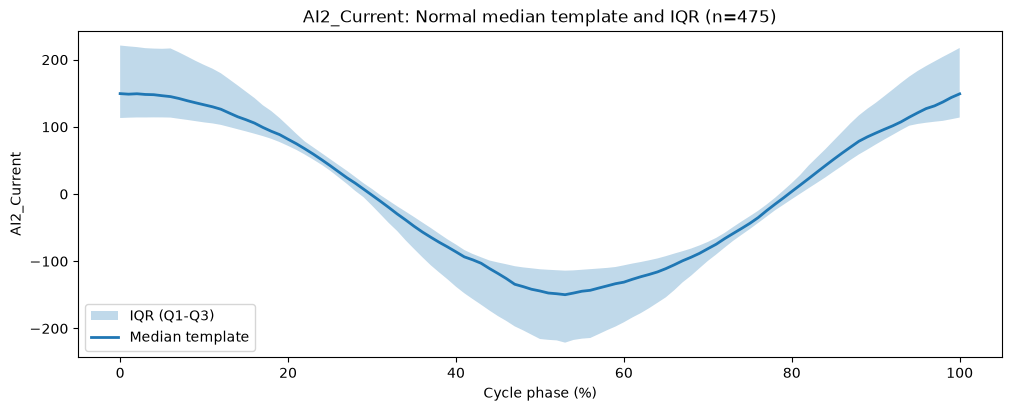

Normal cycle shape consistency:


template_rmse                                             \
                      count       mean     median        std       min   
channel                                                                  
AI0_Vibration           475   0.054241   0.053097   0.018999  0.016724   
AI1_Vibration           475   0.091143   0.079738   0.053551  0.020248   
AI2_Current             475  34.359708  24.194145  21.728585  4.410524   

                         template_correlation                                \
                     max                count      mean    median       std   
channel                                                                       
AI0_Vibration   0.145157                  475  0.103222  0.139027  0.323516   
AI1_Vibration   0.202622                  475  0.056828  0.070420  0.228241   
AI2_Current    84.686900                  475  0.994940  0.996505  0.004384   

                                   
                    min       max  
channel                            
AI0_Vibration -0.771237  0.831727  
AI1_Vibration -0.596515  0.607888  
AI2_Current    0.968304  0.999648

In [8]:
waveforms_by_channel={
    channel:{
        (item["segment_id"],item["cycle_number_in_segment"]):item["values"]
        for item in cycle_waveforms if item["channel"]==channel
    }
    for channel in CHANNELS
}

cycle_keys=sorted(waveforms_by_channel[CYCLE_ANCHOR].keys())
phase_percent=np.linspace(0,100,TEMPLATE_PHASE_POINTS)

rng=np.random.default_rng(20260928)
overlay_count=min(80,len(cycle_keys))
overlay_idx=np.sort(rng.choice(len(cycle_keys),size=overlay_count,replace=False))
overlay_keys=[cycle_keys[i] for i in overlay_idx]

for channel in CHANNELS:
    fig,ax=plt.subplots(figsize=(10,4),constrained_layout=True)
    for key in overlay_keys:
        ax.plot(phase_percent,waveforms_by_channel[channel][key],alpha=.12,lw=.8)
    ax.set(
        title=f"{channel}: phase-normalized Normal cycles (n={overlay_count})",
        xlabel="Cycle phase (%)",
        ylabel=channel
    )
    plt.show()

cycle_shape_metrics=[]

for channel in CHANNELS:
    matrix=np.vstack([waveforms_by_channel[channel][key] for key in cycle_keys])
    q1=np.quantile(matrix,.25,axis=0)
    median=cycle_templates[channel]
    q3=np.quantile(matrix,.75,axis=0)

    fig,ax=plt.subplots(figsize=(10,4),constrained_layout=True)
    ax.fill_between(phase_percent,q1,q3,alpha=.28,label="IQR (Q1-Q3)")
    ax.plot(phase_percent,median,lw=2,label="Median template")
    ax.set(
        title=f"{channel}: Normal median template and IQR (n={len(matrix)})",
        xlabel="Cycle phase (%)",
        ylabel=channel
    )
    ax.legend()
    plt.show()

    for key,values in zip(cycle_keys,matrix):
        rmse=float(np.sqrt(np.mean((values-median)**2)))
        corr=float(np.corrcoef(values,median)[0,1]) if np.std(values)>0 and np.std(median)>0 else np.nan

        cycle_shape_metrics.append({
            "channel":channel,
            "segment_id":key[0],
            "cycle_number_in_segment":key[1],
            "template_rmse":rmse,
            "template_correlation":corr
        })

cycle_shape_metrics=pd.DataFrame(cycle_shape_metrics)

shape_summary=cycle_shape_metrics.groupby("channel")[
    ["template_rmse","template_correlation"]
].agg(["count","mean","median","std","min","max"])

print("Normal cycle shape consistency:")
display(shape_summary)